In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
df = pd.read_csv("/content/Algerian_forest_fires_dataset_CLEANED.csv")

In [22]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [23]:
df = df.drop(columns=["day", "month", "year"])

In [24]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


Encoding classes column

In [25]:
df["Classes"] = np.where(df["Classes"].str.contains("not fire"), 0, 1)

In [26]:
df["Classes"].value_counts()

,count
Classes,
1,137
0,106


Segregating into dependent and independent features

In [27]:
X = df.drop(columns=["FWI"])
y = df["FWI"]

Splitting data into training data and testing data

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

Feature Selection


In [29]:
def correlation(dataset, threshold):
  col_corr = set()
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j])>threshold:
        colname = corr_matrix.columns[i]
        col_corr.add(colname)
  return col_corr

In [30]:
corr_feats = correlation(X_train, 0.85)
corr_feats

{'BUI', 'DC'}

In [31]:
X_train.drop(corr_feats, axis=1, inplace=True)
X_test.drop(corr_feats, axis=1, inplace=True)

Standardization

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: title={'center': 'After scaling'}>

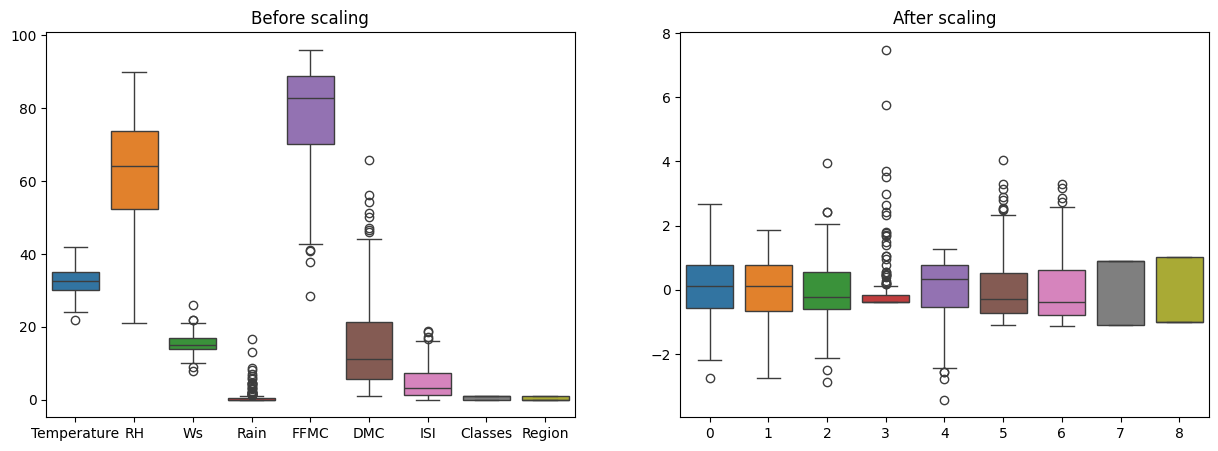

In [33]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title("Before scaling")
sns.boxplot(X_train)
plt.subplot(1,2, 2)
plt.title("After scaling")
sns.boxplot(X_train_scaled)

# **Linear Regression**

Mean squared Error: 0.6742766873791607
R2 Score: 0.9847657384266951


Text(0, 0.5, 'Predicted')

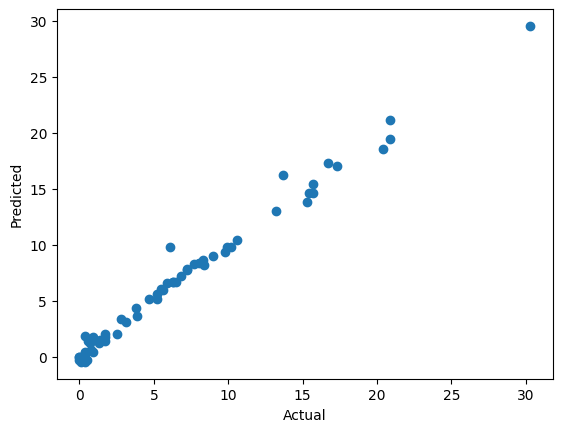

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

# **Lasso Regression**

Mean squared Error: 2.2483458918974772
R2 Score: 0.9492020263112388


Text(0, 0.5, 'Predicted')

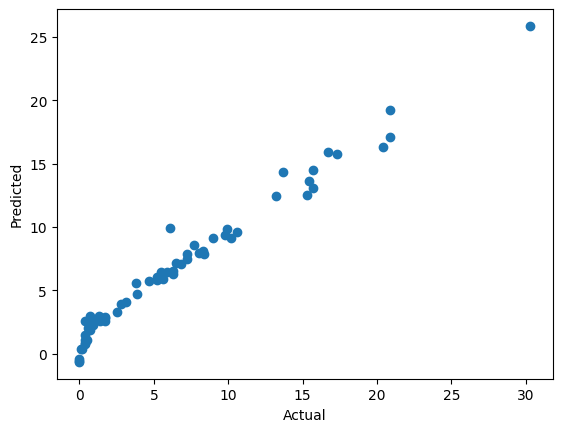

In [35]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

# **Cross Validation Lasso**

Mean squared Error: 0.792499555474362
R2 Score: 0.9820946715928275


Text(0, 0.5, 'Predicted')

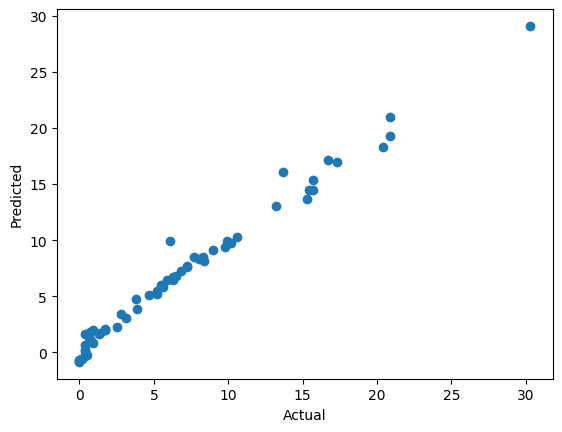

In [36]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV()
lassocv.fit(X_train_scaled, y_train)
y_pred = lassocv.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

# **Ridge Regression**

Mean squared Error: 0.6949198918152074
R2 Score: 0.9842993364555513


Text(0, 0.5, 'Predicted')

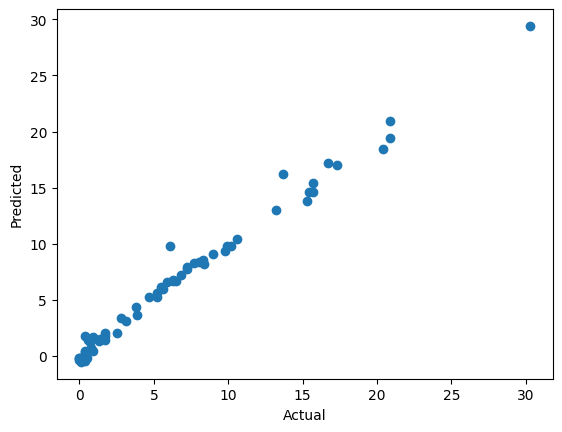

In [37]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

# **Cross Validation Ridge**

Mean squared Error: 0.6949198918151805
R2 Score: 0.9842993364555519


Text(0, 0.5, 'Predicted')

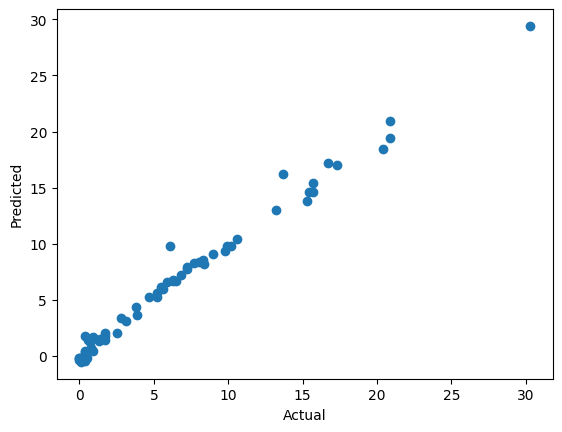

In [38]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV()
ridgecv.fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

# **Elastic Net Regression**

Mean squared Error: 5.5172511010252245
R2 Score: 0.8753460589519703


Text(0, 0.5, 'Predicted')

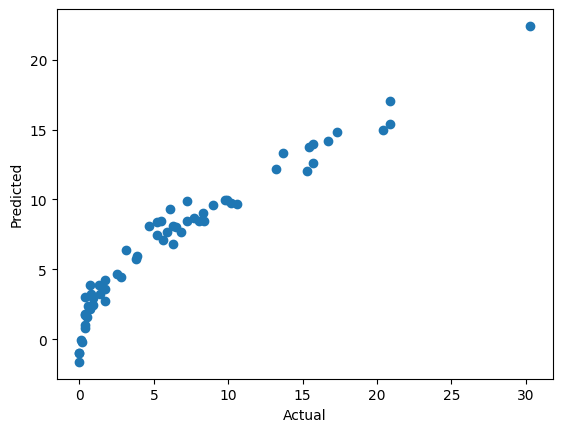

In [40]:
from sklearn.linear_model import ElasticNet
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled, y_train)
y_pred = elasticnet.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

# **Cross Validation ELasticNet**

Mean squared Error: 0.8222830416276258
R2 Score: 0.9814217587854941


Text(0, 0.5, 'Predicted')

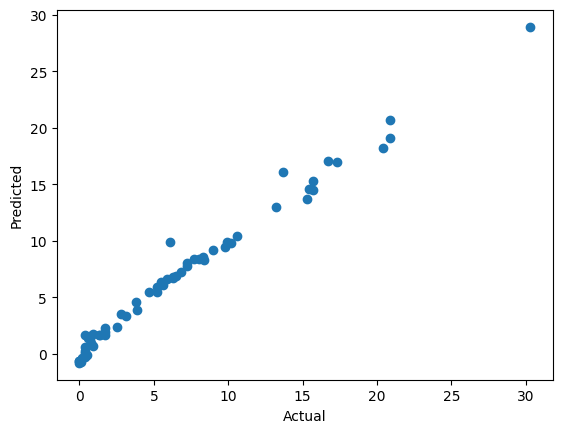

In [41]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV()
elasticnetcv.fit(X_train_scaled, y_train)
y_pred = elasticnetcv.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean squared Error:", mse)
print("R2 Score:", r2)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

# **Pickling**

In [42]:
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(linreg, open("linreg.pkl", "wb"))